In [1]:
import scanpy as sc
import pandas as pd
import hotspot
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import leaves_list
import plotly.express as px

In [11]:
hs = joblib.load(
    "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/epi_hs.create_modules_velocity_pseudotime.pkl"
)
adata = sc.read(
    "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/epi_hs.adata_velocity_pseudotime.h5ad"
)

In [12]:
output_path = "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/"

In [13]:
modules = hs.create_modules(min_gene_threshold=160, core_only=True, fdr_threshold=0.01)

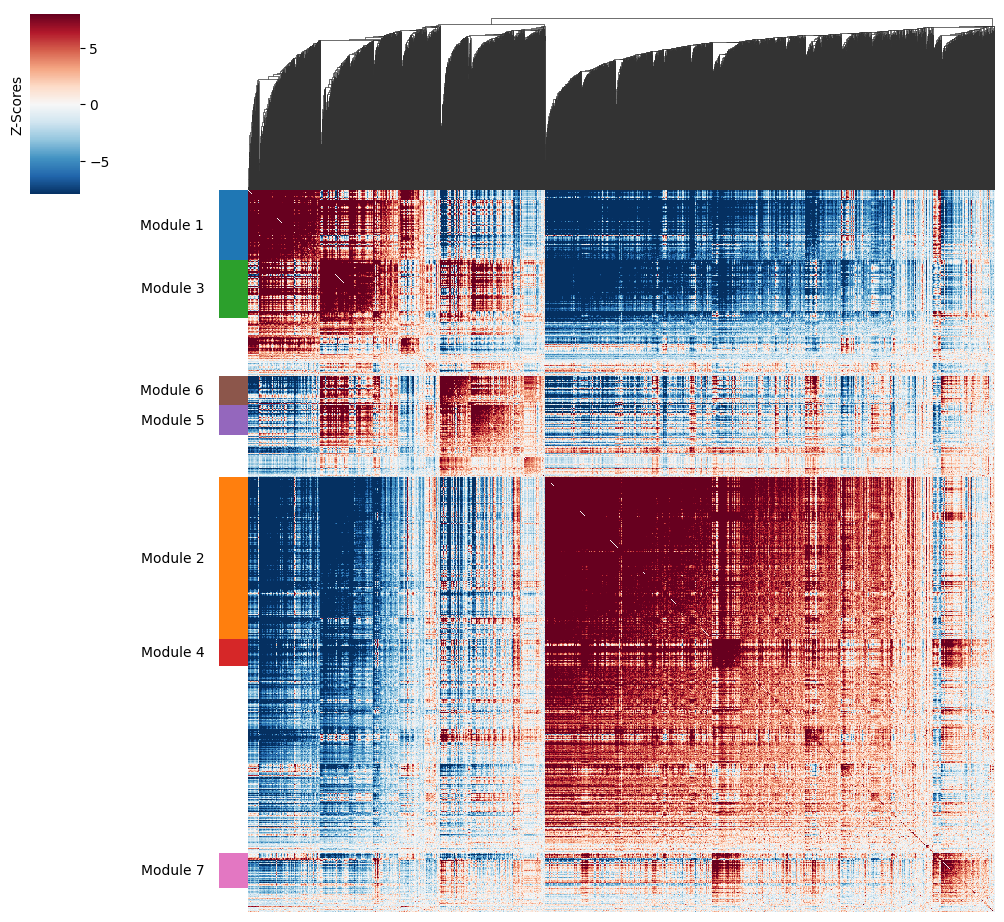

In [15]:
hs.plot_local_correlations()
fig = plt.gcf()
fig.set_size_inches(10, 10)
plt.savefig(
    output_path + "epi_plot_local_correlations.pdf",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
)

In [16]:
ii = leaves_list(hs.linkage)

mod_reordered = hs.modules.iloc[ii]

mod_map = {}
y = np.arange(modules.size)

for x in mod_reordered.unique():
    if x == -1:
        continue

mod_map[x] = y[mod_reordered == x].mean()

mod_reordered.to_csv(
    output_path + "mod_reordered.csv"
)

In [17]:
module_scores = hs.calculate_module_scores()

adata.obs["Module1"] = module_scores.loc[adata.obs.index, 1].values
adata.obs["Module2"] = module_scores.loc[adata.obs.index, 2].values
adata.obs["Module3"] = module_scores.loc[adata.obs.index, 3].values
adata.obs["Module4"] = module_scores.loc[adata.obs.index, 4].values
adata.obs["Module5"] = module_scores.loc[adata.obs.index, 5].values
adata.obs["Module6"] = module_scores.loc[adata.obs.index, 6].values
adata.obs["Module7"] = module_scores.loc[adata.obs.index, 7].values

adata.obs.to_csv(output_path + "/epi_Module_gene_score.csv")


Computing scores for 7 modules...


100%|██████████| 7/7 [00:07<00:00,  1.02s/it]


In [18]:
modules = [f"Module{i}" for i in range(1, 8)]  # ["Module1", ..., "Module7"]

for module in modules:
    plt.clf()
    sc.pl.umap(
        adata,
        color=module,
        vmax=6,
        frameon=False,
        show=False
    )
    fig = plt.gcf()
    ax = plt.gca()
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(f"{module}", fontsize=40)

    fig.savefig(
        f"{output_path}/epi_{module}_gene_score.pdf",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )
    plt.close(fig)

<Figure size 640x480 with 0 Axes>